# 🎾 Huấn Luyện & Debugging Tennis Court Line Detector (Keras 3 / GPU Accelerated)

Notebook này sử dụng kiến trúc **ResNet50 Regression (Keras 3 / TensorFlow)** với tính năng tăng tốc trực tiếp trên card **NVIDIA GeForce RTX 5060 Laptop GPU (CUDA 13.0)** để phát hiện 14 điểm mốc (keypoints) của sân quần vợt:
1. **Tăng tốc GPU RTX 5060**: Sử dụng backend PyTorch của Keras 3 để tận dụng sức mạnh GPU (thay vì chạy CPU chậm chạp trên Windows).
2. **Tự động điều chỉnh working directory**: Tránh lỗi đường dẫn tương đối khi chạy trên Jupyter.
3. **Chế độ Debug & Synthetic Data**: Nếu chưa có tập dữ liệu `data.json`, notebook tự động tạo dữ liệu mẫu để bạn debug kiểm tra toàn bộ pipeline huấn luyện không bị ngắt quãng.
4. **Vẽ biểu đồ Loss (MSE) & MAE**: Tự động lưu biểu đồ huấn luyện và hiển thị trực quan các điểm mốc dự đoán (Ground Truth màu xanh vs Predicted màu đỏ).

## 1. Thiết Lập Môi Trường Keras 3 & Tăng Tốc GPU RTX 5060
Kích hoạt backend PyTorch/CUDA cho Keras 3 để huấn luyện trực tiếp trên GPU máy bạn.

In [1]:
import os
import sys

# Kích hoạt backend PyTorch cho Keras 3 để khai thác tối đa sức mạnh GPU RTX 5060 (CUDA 13.0)
os.environ["KERAS_BACKEND"] = "torch"

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
import torch

# Tự động điều chỉnh working directory về root dự án
current_dir = os.getcwd()
if os.path.basename(current_dir) == "training":
    os.chdir("..")
project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"📁 Thư mục làm việc: {project_root}")
backend_name = keras.backend.backend()
print(f"⚡ Keras Version: {keras.__version__} (Backend: {backend_name})")

# Kiểm tra và kích hoạt GPU
if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    total_vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"🚀 GPU ĐÃ KÍCH HOẠT THÀNH CÔNG: {device_name}")
    print(f"   - CUDA Version: {torch.version.cuda}")
    print(f"   - Thiết bị thực thi: cuda:0")
    print(f"   - Tổng VRAM vật lý: {total_vram:.2f} GB")
else:
    print("ℹ️ Đang chạy trên CPU.")

if backend_name != "torch":
    print("\n⚠️ CẢNH BÁO QUAN TRỌNG:")
    print(f"   Keras hiện vẫn đang giữ backend '{backend_name}' từ phiên cũ (chỉ chạy CPU).")
    print("👉 BẮT BUỘC: Hãy bấm nút 🔄 RESTART KERNEL trên thanh công cụ Notebook rồi chạy lại Cell 1 để kích hoạt GPU RTX 5060!")
else:
    print("🔥 Backend Keras 'torch' đã kết nối trực tiếp với CUDA 13.0 trên RTX 5060! Sẵn sàng huấn luyện siêu tốc.")


📁 Thư mục làm việc: d:\FPT\DAT301m\tennis_analysis-main
⚡ Keras Version: 3.12.4 (Backend: torch)
🚀 GPU ĐÃ KÍCH HOẠT THÀNH CÔNG: NVIDIA GeForce RTX 5060 Laptop GPU
   - CUDA Version: 13.0
   - Thiết bị thực thi: cuda:0
   - Tổng VRAM vật lý: 7.93 GB
🔥 Backend Keras 'torch' đã kết nối trực tiếp với CUDA 13.0 trên RTX 5060! Sẵn sàng huấn luyện siêu tốc.


## 2. Nạp Dữ Liệu Sân Quần Vợt & Chế Độ Debug
Đọc ảnh sân và 14 điểm mốc từ `training/datasets/court/tennis_court_keypoints/data.json`. Nếu chưa có dữ liệu thực, hệ thống sẽ tự động khởi tạo dữ liệu mô phỏng để debug.

In [2]:
from training.train_court_line_detector_tf import load_court_data

IMG_DIR = "training/datasets/court/tennis_court_keypoints"
ANNOTATION_FILE = "training/datasets/court/tennis_court_keypoints/data.json"

if os.path.exists(ANNOTATION_FILE):
    # Bạn có thể đổi max_samples=None nếu muốn nạp toàn bộ 10,000 ảnh (yêu cầu RAM >= 16GB)
    MAX_SAMPLES = 1000
    X, y, raw_images = load_court_data(IMG_DIR, ANNOTATION_FILE, max_samples=MAX_SAMPLES)
    print(f"✅ Đã nạp thành công {len(X)} ảnh từ dataset {ANNOTATION_FILE}")
    print(f"   - Shape ảnh đầu vào (X): {X.shape}")
    print(f"   - Shape tọa độ nhãn (y): {y.shape} (14 điểm x 2 tọa độ = 28 giá trị)")
else:
    print(f"ℹ️ Không tìm thấy {ANNOTATION_FILE}.")
    print("🛠️ Khởi tạo 32 mẫu synthetic court data để bạn kiểm tra debug toàn diện pipeline...")
    np.random.seed(42)
    X = np.random.randn(32, 224, 224, 3).astype(np.float32)
    y = np.random.uniform(20.0, 204.0, size=(32, 28)).astype(np.float32)
    raw_images = [np.clip(np.uint8((x + 2.0) * 50), 0, 255) for x in X]
    print(f"✅ Đã tạo {len(X)} mẫu debug: X={X.shape}, y={y.shape}")

✅ Đã nạp thành công 1000 ảnh từ dataset training/datasets/court/tennis_court_keypoints/data.json
   - Shape ảnh đầu vào (X): (1000, 224, 224, 3)
   - Shape tọa độ nhãn (y): (1000, 28) (14 điểm x 2 tọa độ = 28 giá trị)


## 3. Visual Debugging: Hiển Thị Mẫu Điểm Mốc Trên Sân
Hiển thị trực quan 4 mẫu dữ liệu với 14 điểm mốc được chấm màu xanh lá.

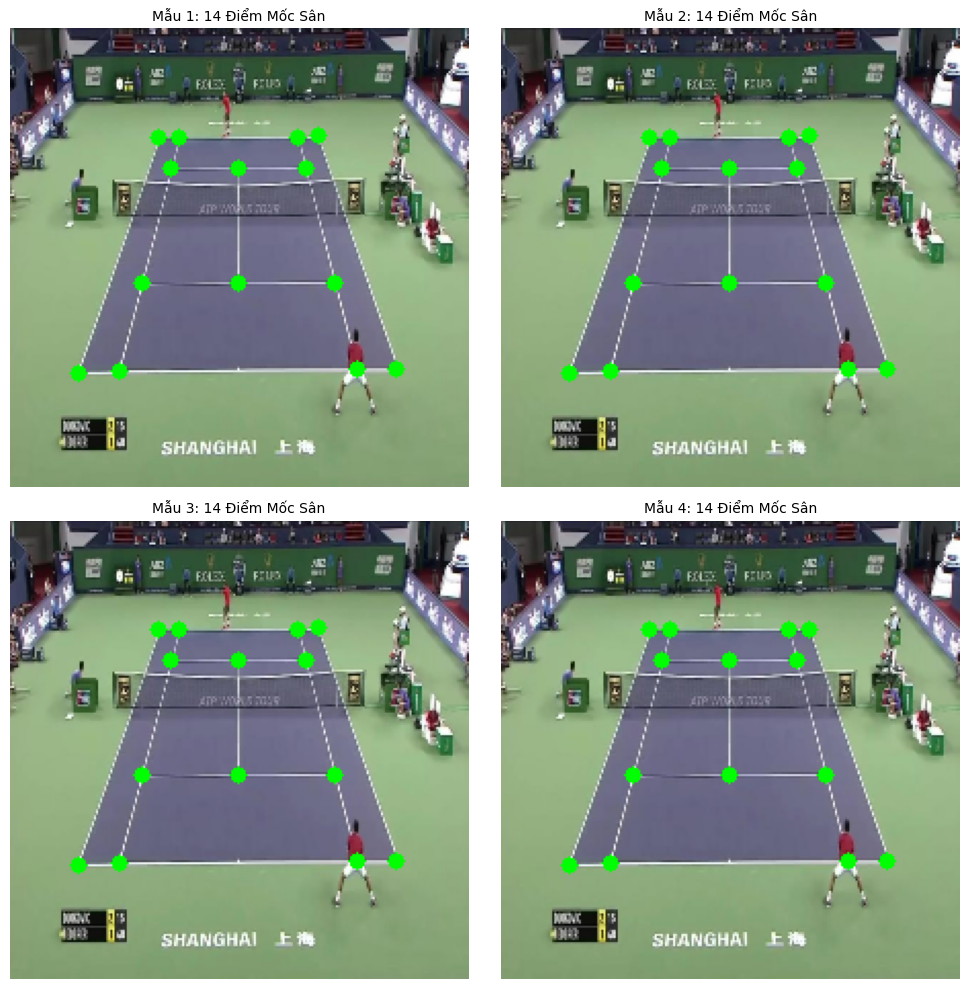

🔍 Điểm màu xanh lá: 14 keypoints của sân tennis.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i in range(min(4, len(raw_images))):
    sample_img = cv2.resize(raw_images[i].copy(), (224, 224))
    kps = y[i]
    for j in range(0, len(kps), 2):
        px, py = int(kps[j]), int(kps[j+1])
        cv2.circle(sample_img, (px, py), 4, (0, 255, 0), -1)
    axes[i].imshow(sample_img)
    axes[i].set_title(f"Mẫu {i+1}: 14 Điểm Mốc Sân", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()
print("🔍 Điểm màu xanh lá: 14 keypoints của sân tennis.")

## 4. Xây Dựng Kiến Trúc ResNet50 & Huấn Luyện Tăng Tốc Trên GPU RTX 5060
Mô hình sử dụng mạng ResNet50 trích xuất đặc trưng và khối Dense regression để dự đoán 28 giá trị tọa độ.

In [5]:
from court_line_detector import CourtLineDetector

# Khởi tạo detector ResNet50 (tự động chạy trên GPU RTX 5060)
detector = CourtLineDetector()
model = detector.model
print(f"✅ Kiến trúc ResNet50 (Keras 3 / GPU) đã sẵn sàng. Tổng tham số: {model.count_params():,}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

os.makedirs("models", exist_ok=True)
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("models/keypoints_model.keras", monitor="val_loss", save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6)
]

# Chia tập Train / Val
split_idx = int(len(X) * 0.85)
if split_idx == 0:
    split_idx = len(X)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]
raw_val = raw_images[split_idx:] if split_idx < len(raw_images) else raw_images

# Chế độ huấn luyện trên GPU
EPOCHS = 10 if not os.path.exists(ANNOTATION_FILE) else 50
BATCH_SIZE = 16   # Kích thước batch tối ưu cho GPU RTX 5060 (8GB VRAM)

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"🎮 Card đồ họa: {torch.cuda.get_device_name(0)}")
    print(f"📊 VRAM trước khi train: {torch.cuda.memory_allocated(0)/(1024**2):.1f} MB (Reserved: {torch.cuda.memory_reserved(0)/(1024**2):.1f} MB)")

print(f"🚀 Bắt đầu huấn luyện {EPOCHS} epochs trên GPU RTX 5060...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val) if len(X_val) > 0 else None,
    callbacks=callbacks,
    verbose=1
)

if torch.cuda.is_available():
    print(f"📊 VRAM đỉnh điểm khi huấn luyện: {torch.cuda.memory_allocated(0)/(1024**2):.1f} MB (Peak Reserved: {torch.cuda.memory_reserved(0)/(1024**2):.1f} MB / ~{torch.cuda.memory_reserved(0)/(1024**3):.2f} GB)")

# Lưu mô hình định dạng chuẩn Keras
model.save("models/keypoints_model.keras")
try:
    model.save("models/keypoints_model.h5")
except Exception:
    pass
print("💾 Đã lưu mô hình thành công vào models/keypoints_model.keras & models/keypoints_model.h5!")


✅ Kiến trúc ResNet50 (Keras 3 / GPU) đã sẵn sàng. Tổng tham số: 24,119,452
🎮 Card đồ họa: NVIDIA GeForce RTX 5060 Laptop GPU
📊 VRAM trước khi train: 92.0 MB (Reserved: 144.0 MB)
🚀 Bắt đầu huấn luyện 50 epochs trên GPU RTX 5060...
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 10941.6377 - mae: 95.2554 - val_loss: 11513.2021 - val_mae: 97.9949 - learning_rate: 1.0000e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 29s 540ms/step - loss: 3989.9666 - mae: 52.0926 - val_loss: 9091.4287 - val_mae: 86.3773 - learning_rate: 1.0000e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 29s 547ms/step - loss: 838.1992 - mae: 21.7986 - val_loss: 9043.4238 - val_mae: 86.9055 - learning_rate: 1.0000e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 28s 516ms/step - loss: 389.8560 - mae: 15.5811 - val_loss: 10041.2119 - val_mae: 91.8570 - learning_rate: 1.0000e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 28s 522ms/step - loss: 333.8522 - mae: 14.4867 - val_loss: 9902.5137 - val_mae: 91.2510 - learning_rate: 1.0000e-0

💾 Đã lưu mô hình thành công vào models/keypoints_model.keras & models/keypoints_model.h5!


## 5. Xuất Biểu Đồ Huấn Luyện (Loss MSE & MAE) & So Sánh Dự Đoán
Tự động vẽ các biểu đồ báo cáo và lưu vào thư mục `reports/court_detector_plots/`.


=== Generating Court Detector Training & Evaluation Charts ===
 -> Saved Loss/MAE Curves: reports/court_detector_plots\court_detector_loss_mae_curves.png


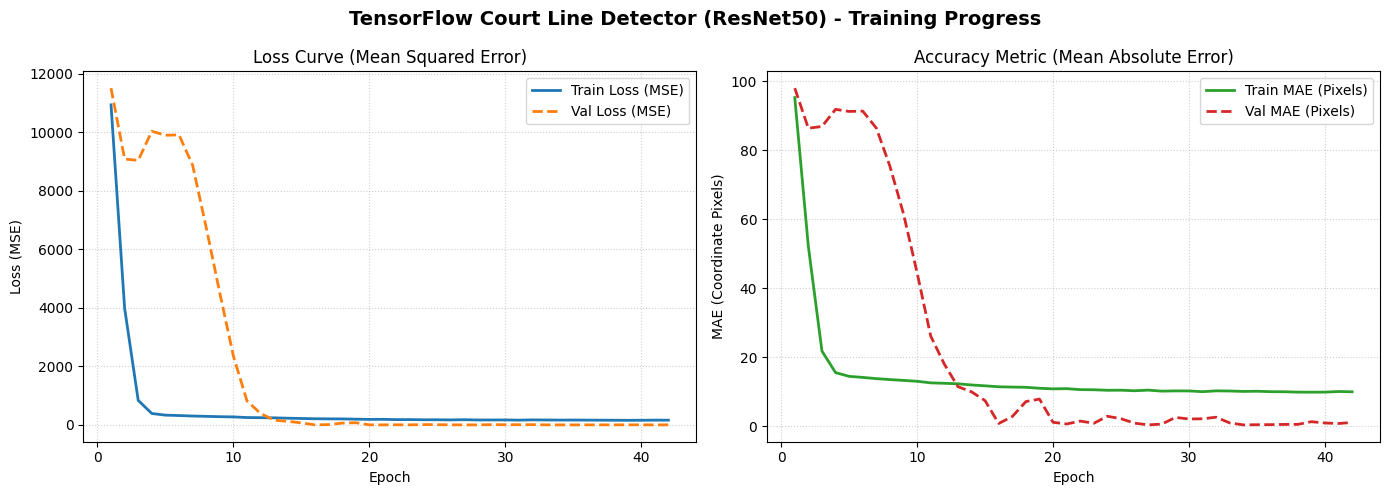

 -> Saved Visual Predictions Chart: reports/court_detector_plots\court_keypoints_visual_predictions.png


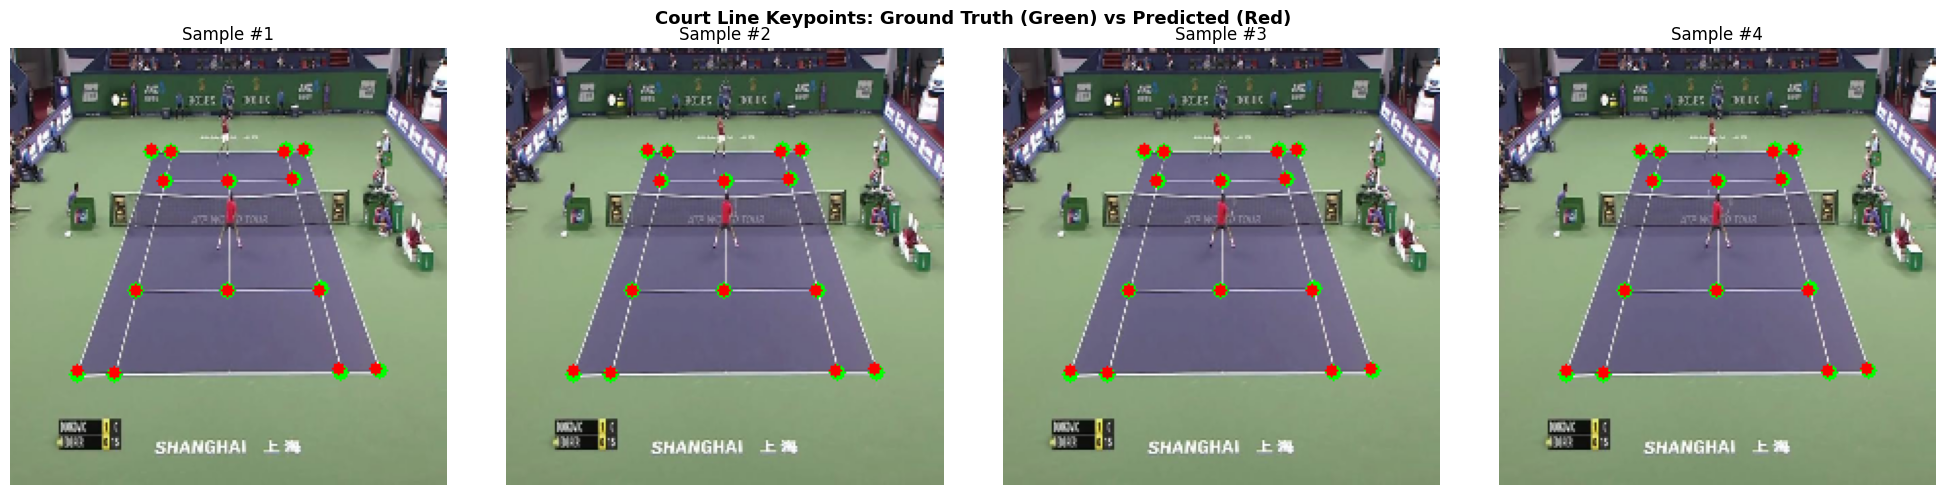

=== All court detector plots saved to: d:\FPT\DAT301m\tennis_analysis-main\reports\court_detector_plots ===

📈 Biểu đồ Loss (MSE) và MAE:


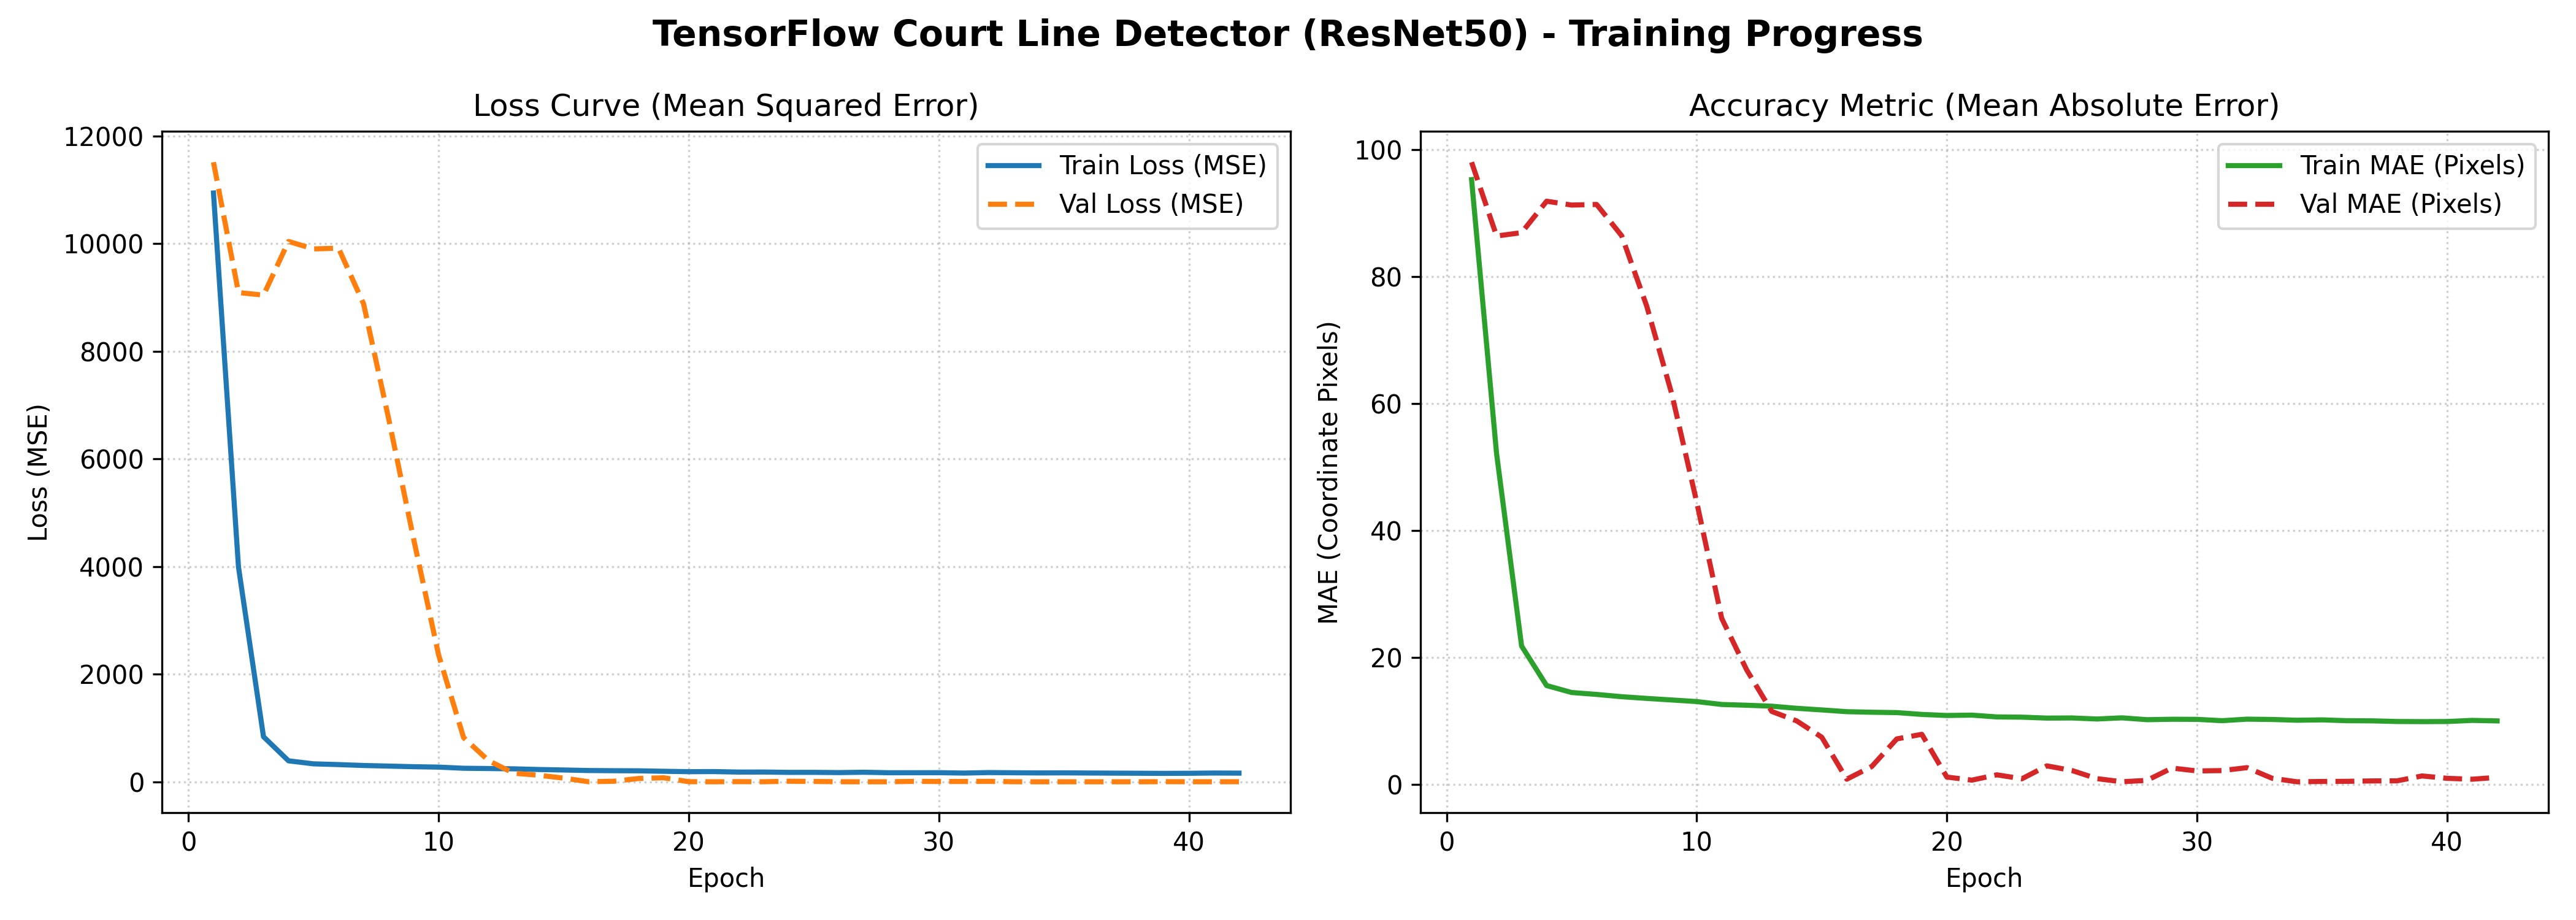

🎯 So sánh trực quan: Điểm thực tế (Xanh lá) vs Điểm dự đoán (Đỏ):


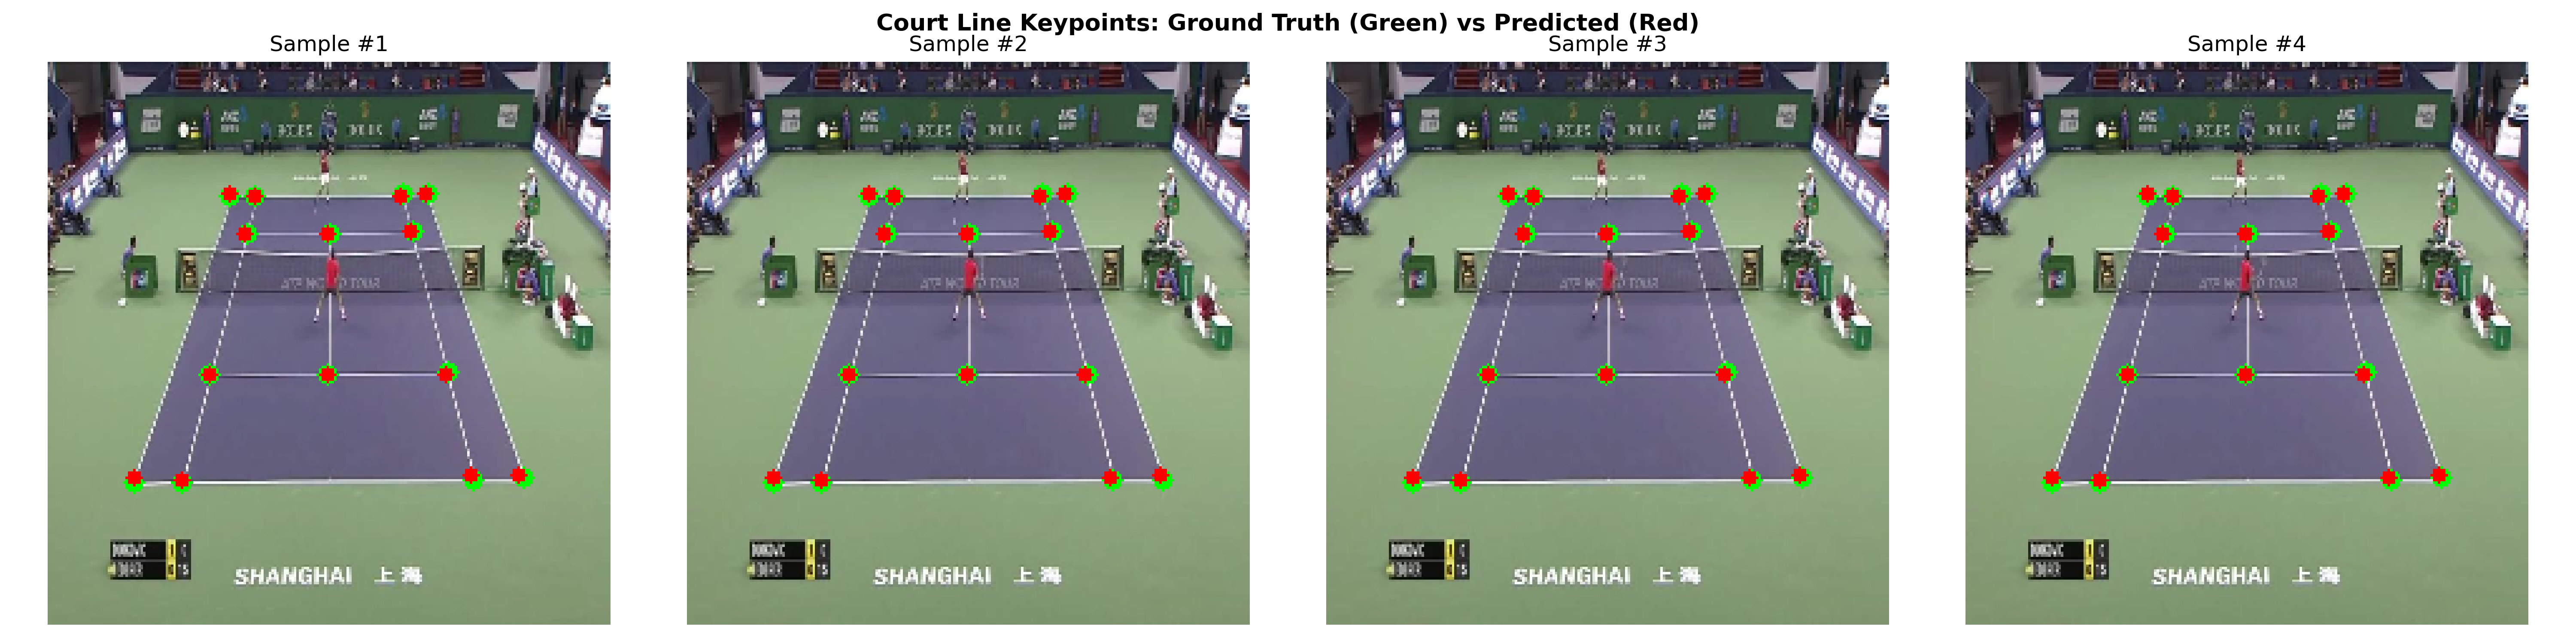

🎉 Toàn bộ quá trình hoàn tất! Mô hình vạch sân TensorFlow đã sẵn sàng.


In [6]:
from training.train_court_line_detector_tf import plot_court_training_results
from IPython.display import Image, display

save_court_dir = "reports/court_detector_plots"
os.makedirs(save_court_dir, exist_ok=True)

if 'history' in locals() and history is not None:
    eval_X = X_val if len(X_val) > 0 else X_train
    eval_y = y_val if len(y_val) > 0 else y_train
    plot_court_training_results(history, model, eval_X, eval_y, raw_val, save_dir=save_court_dir)
    
    loss_chart = os.path.join(save_court_dir, "court_detector_loss_mae_curves.png")
    pred_chart = os.path.join(save_court_dir, "court_keypoints_visual_predictions.png")
    
    if os.path.exists(loss_chart):
        print("📈 Biểu đồ Loss (MSE) và MAE:")
        display(Image(filename=loss_chart))
    if os.path.exists(pred_chart):
        print("🎯 So sánh trực quan: Điểm thực tế (Xanh lá) vs Điểm dự đoán (Đỏ):")
        display(Image(filename=pred_chart))

print("🎉 Toàn bộ quá trình hoàn tất! Mô hình vạch sân TensorFlow đã sẵn sàng.")